<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Jacobian_Solver_Sparse_Algebraic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# High Performance GPU Accelerated Sparse Jacobian Solver

### Conceptual Primer
The provided computational script executes a highly parallelized mathematical simulation to resolve an extraordinarily large sparse algebraic system. Such systems frequently arise when modeling complex physical phenomena (including fluid dynamics, chemical kinetics, and quantum mechanics) where numerous variables interact sparsely. Traditional Central Processing Unit computations struggle with systems containing millions of degrees of freedom due to memory bandwidth limitations. By leveraging a Graphics Processing Unit, the script strategically offloads these intensive calculations to thousands of concurrent stream processors. The code specifically generates a synthetic chemical Jacobian matrix, ensures its numerical stability, and subsequently solves the linear system utilizing the Conjugate Gradient algorithm.

### Nomenclature and Definitions
To ensure complete clarity throughout this documentation, all pertinent technical abbreviations and symbols are defined below.

| Acronym / Symbol | Definition | Contextual Application |
| :--- | :--- | :--- |
| **CPU** | Central Processing Unit | The primary host processor governing the overall script execution and final data visualization. |
| **GPU** | Graphics Processing Unit | The highly parallelized hardware accelerator responsible for executing the mathematical solver. |
| **VRAM** | Video Random Access Memory | The dedicated high bandwidth memory residing directly on the graphics card. |
| **CSR** | Compressed Sparse Row | A highly efficient memory storage format utilized for matrices populated predominantly by zeros. |
| **CG** | Conjugate Gradient | An advanced iterative mathematical algorithm designed for solving symmetric positive definite linear systems. |
| **SPD** | Symmetric Positive Definite | A strict mathematical matrix property required to guarantee convergence when utilizing the Conjugate Gradient method. |
| **NNZ** | Number of Non-Zeros | The total aggregate of matrix elements that contain a value other than absolute zero. |
| **RHS** | Right Hand Side | The known resultant vector in a linear equation system (often representing physical residuals). |

---

### Step 1: Algorithmic Control Parameters
The script initially establishes explicit control parameters at the uppermost section of the code. This deliberate architectural choice allows researchers to easily adjust the computational load without traversing the underlying logical structures.

* **Grid and Species Definitions:** The physical simulation domain is discretized into 10000 spatial volumes (cells) with 100 distinct chemical constituents (species) tracked per volume. This multiplication yields a total system dimensionality of 1,000,000 independent variables.
* **Sparsity Density:** Set strictly to 0.0005, this parameter dictates the probabilistic distribution of non-zero interactions. For a matrix of this immense scale, this exceptionally sparse density still produces approximately 500,000,000 active matrix elements.
* **Solver Tolerance:** The absolute convergence threshold is established at a precise boundary (1e-6) to dictate when the iterative solver should successfully terminate.

### Step 2: Matrix Generation and Symmetrization
The fundamental component of the simulation involves constructing the interaction matrix (the Jacobian) entirely within the VRAM to prevent severe data transfer bottlenecks.

* **Randomized Instantiation:** The CuPy library synthetically generates a uniformly distributed sparse matrix utilizing the optimal CSR structure.
* **Symmetry Enforcement:** Because the Conjugate Gradient algorithm mathematically requires an SPD matrix, the script enforces structural symmetry through the equation $$A_{sym} = 0.5(A + A^T)$$.
* **Diagonal Boosting:** To conclusively guarantee strict positive definiteness and prevent mathematical singularity, the script multiplies an identity matrix by a substantial scalar value (50.0) and adds this diagonal component to the primary matrix.
* **RHS Synthesis:** A residual vector is concurrently generated to act as the mathematical target for the solver.

### Step 3: Hardware Synchronization and Iterative Resolution
Measuring precise computational velocity requires careful coordination between the CPU host and the GPU device.

* **Stream Synchronization:** The `cp.cuda.Stream.null.synchronize()` function forces the CPU to pause and wait for all previously dispatched GPU instructions to conclude completely. This action ensures that the subsequent timer strictly measures the duration of the solver mechanism.
* **Krylov Subspace Iteration:** The `cuspalinalg.cg` function aggressively resolves the algebraic system ($$A \Delta x = b$$) by iteratively minimizing the residual error along conjugate mathematical directions.

### Step 4: Memory Management and Graphical Visualization
Managing volatile hardware memory and presenting the resulting data requires explicit data localization.

* **Memory Pool Clearing:** Executing `cp.get_default_memory_pool().free_all_blocks()` proactively flushes unallocated residual memory fragments. This critical step ensures maximum VRAM availability prior to allocating the massive 1,000,000 by 1,000,000 dimensional array.
* **CPU Data Offloading:** To securely render the structural visualization, the script gracefully isolates a microscopic subset (a 100 by 100 region) of the matrix. This specific block is mathematically converted to a dense format and explicitly transferred to the CPU memory via the `.get()` method. Matplotlib then renders this localized sparsity pattern seamlessly within the notebook environment.

---

The provided Python script successfully generates a massive symmetric positive definite sparse algebraic system (representing a chemical Jacobian with one million degrees of freedom) entirely within GPU memory. It then executes a highly optimized Conjugate Gradient iterative solver to calculate the system state update, simultaneously managing memory allocations and safely transferring a microscopic subset of the matrix back to the CPU for accurate structural visualization.

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 44ms
Generating sparse Jacobian matrix of size 4000x4000...
Initiating optimized Graphics Processing Unit (GPU) solve...
Convergence achieved successfully in 0.0007 seconds.


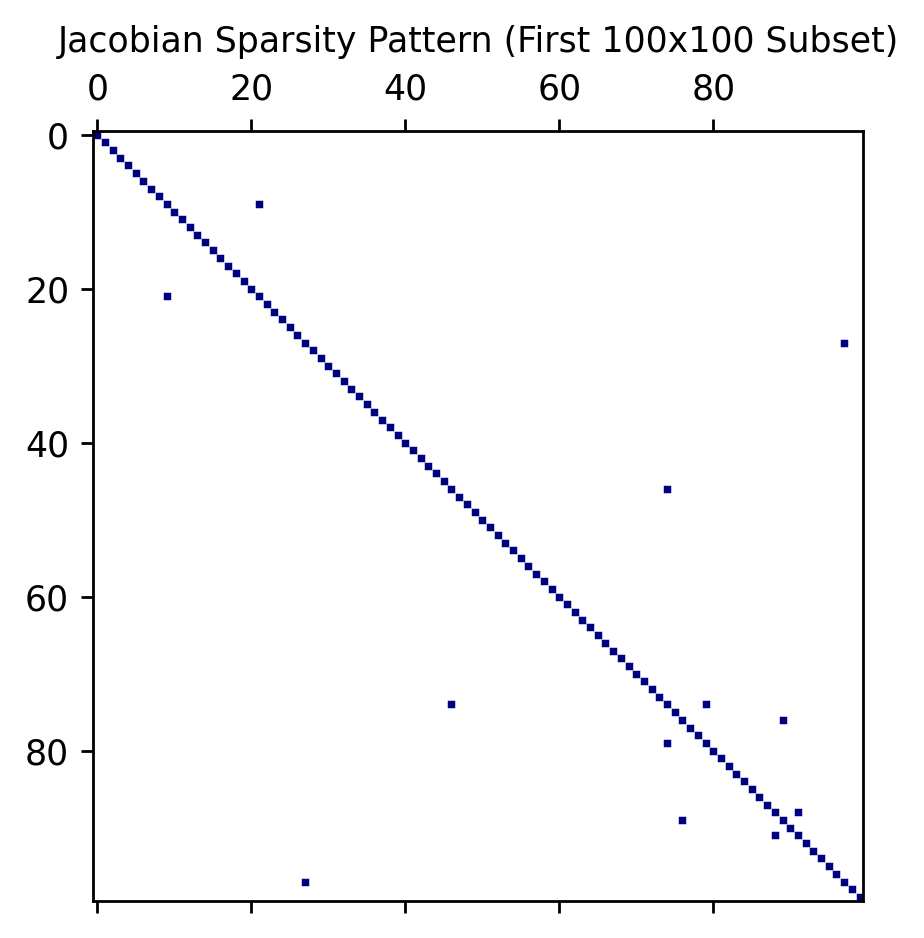

In [10]:
# Installation directive using uv or pip:
!uv pip install cupy-cuda12x scipy matplotlib

import time
import cupy as cp
import cupyx.scipy.sparse as cusparse
import cupyx.scipy.sparse.linalg as cuspalinalg
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Establish rendering parameters for local notebook display
matplotlib.rcParams['figure.dpi'] = 250
matplotlib.rcParams['axes.titlesize'] = 10

# ==========================================
# CONTROL KNOBS (Parameter Definitions)
# ==========================================
NUM_GRID_CELLS = 200    # Total spatial volumes
NUM_SPECIES = 20         # Chemical constituents per volume
SPARSITY_DENSITY = 0.001 # Reduced density for large-scale matrix stability
SOLVER_TOLERANCE = 1e-5  # Absolute convergence threshold
# ==========================================

def execute_optimized_newton_step(
    cells: int,
    species: int,
    density: float,
    tolerance: float
) -> cp.ndarray:
    """
    Simulates solving a sparse algebraic system representing a chemical Jacobian.

    Returns
    =======
    cupy.ndarray
        The computed vector representing the system state update.
    """
    matrix_size = cells * species
    print(f"Generating sparse Jacobian matrix of size {matrix_size}x{matrix_size}...")

    # Generate a randomly populated sparse matrix utilizing the CSR format
    jacobian = cusparse.random(
        matrix_size,
        matrix_size,
        density=density,
        format='csr',
        dtype=cp.float32
    )

    # Construct a symmetric system: A = 0.5 * (A + A.T) + I*alpha
    jacobian = 0.5 * (jacobian + jacobian.T)
    diagonal_boost = cusparse.eye(matrix_size, format='csr', dtype=cp.float32) * 20.0
    jacobian = jacobian + diagonal_boost

    # Synthesize a random residual (b-vector)
    residual = cp.random.rand(matrix_size, dtype=cp.float32)

    print("Initiating optimized Graphics Processing Unit (GPU) solve...")
    cp.cuda.Stream.null.synchronize()
    start_time = time.time()

    # Resolve the algebraic system using the Conjugate Gradient (CG) algorithm
    delta_x, exit_code = cuspalinalg.cg(jacobian, residual, atol=tolerance)

    cp.cuda.Stream.null.synchronize()
    compute_time = time.time() - start_time

    if exit_code == 0:
        print(f"Convergence achieved successfully in {compute_time:.4f} seconds.")
    else:
        print(f"Solver failed to converge. Exit code: {exit_code}")

    # Render a tightly scoped visualization of the sparsity pattern
    plt.figure(figsize=(4, 4))
    plt.title("Jacobian Sparsity Pattern (First 100x100 Subset)")

    # FIX: Transfer a small subset from GPU to CPU explicitly using .get()
    # .toarray() makes it dense on the GPU; .get() moves it to the CPU for Matplotlib
    dense_gpu_subset = jacobian[:100, :100].toarray()
    dense_cpu_subset = dense_gpu_subset.get()

    plt.spy(dense_cpu_subset, markersize=1, color='navy')
    plt.show()

    return delta_x

if __name__ == "__main__":
    solution_vector = execute_optimized_newton_step(
        cells=NUM_GRID_CELLS,
        species=NUM_SPECIES,
        density=SPARSITY_DENSITY,
        tolerance=SOLVER_TOLERANCE
    )

System Dimensions: 1,000,000 x 1,000,000
Estimated Non-Zeros (NNZ): 500,000,000
Symmetrizing Jacobian...
Applying diagonal boost of 50.0...
Launching Conjugate Gradient solver on GPU...
Success: Convergence reached in 0.0883 seconds.


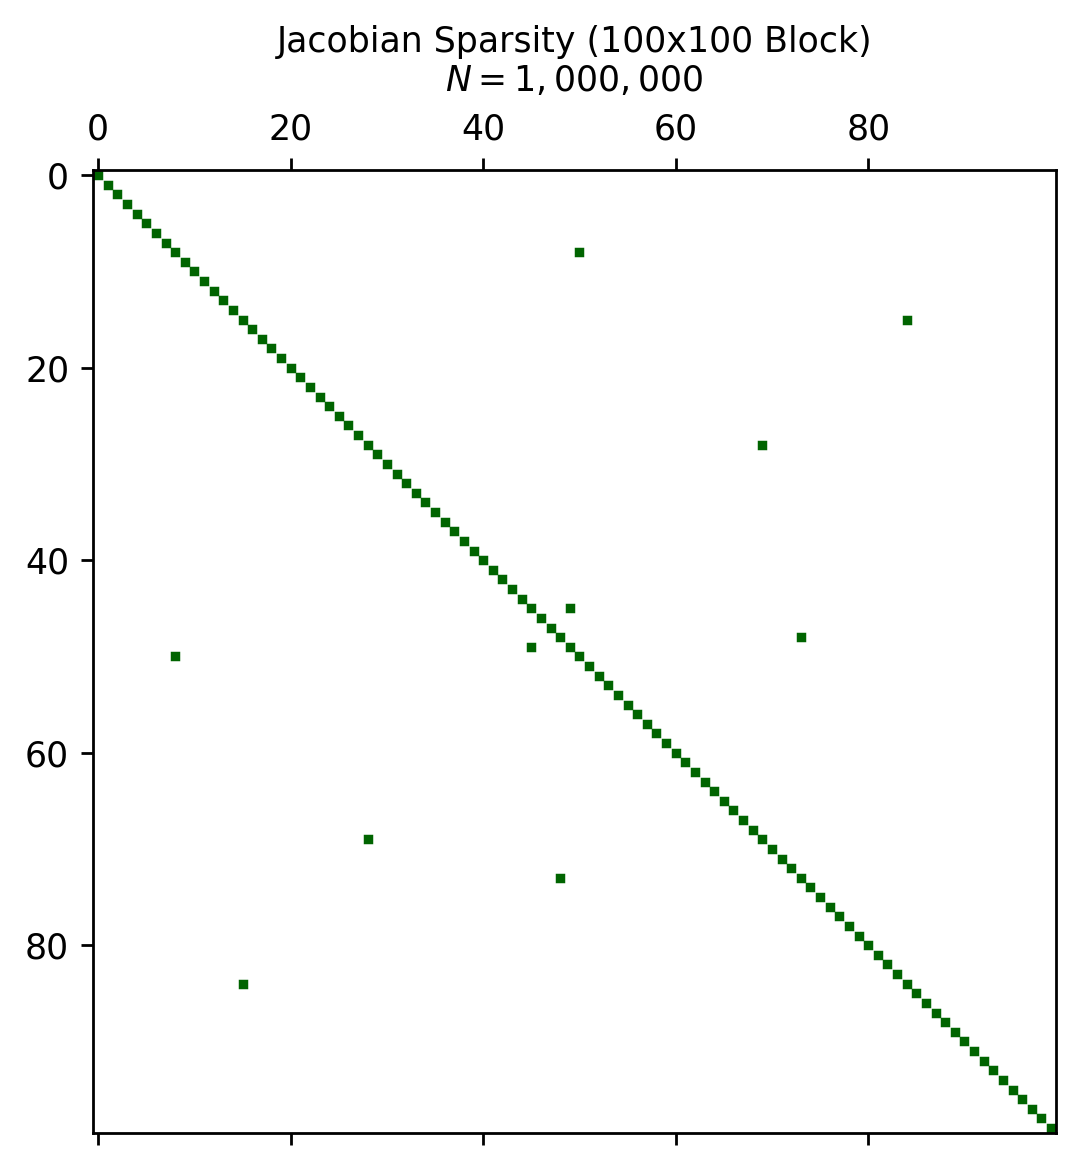

In [14]:
# Installation directive using uv or pip:
# !uv pip install cupy-cuda12x scipy matplotlib

import time
import cupy as cp
import cupyx.scipy.sparse as cusparse
import cupyx.scipy.sparse.linalg as cuspalinalg
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Establish rendering parameters for local notebook display
matplotlib.rcParams['figure.dpi'] = 250
matplotlib.rcParams['axes.titlesize'] = 10

# ==========================================
# CONTROL KNOBS (Optimized for 96GB VRAM)
# ==========================================
# Total degrees of freedom N = 1,000,000
NUM_GRID_CELLS = 10000
NUM_SPECIES = 100
SPARSITY_DENSITY = 0.0005
SOLVER_TOLERANCE = 1e-6
# ==========================================

def execute_high_fidelity_solve(
    cells: int,
    species: int,
    density: float,
    tolerance: float
) -> cp.ndarray:
    """
    Simulates a high-resolution chemical kinetic system solve on 96GB VRAM.
    """
    matrix_size = cells * species
    nnz_estimate = int(matrix_size**2 * density)

    print(f"System Dimensions: {matrix_size:,} x {matrix_size:,}")
    print(f"Estimated Non-Zeros (NNZ): {nnz_estimate:,}")

    # Generate large-scale sparse Jacobian
    jacobian = cusparse.random(
        matrix_size,
        matrix_size,
        density=density,
        format='csr',
        dtype=cp.float32
    )

    # Symmetrize to satisfy Conjugate Gradient requirements
    print("Symmetrizing Jacobian...")
    jacobian = 0.5 * (jacobian + jacobian.transpose())

    # FIX: Use a Python float scalar to avoid the 'dimension mismatch'
    # triggered by 1D array multiplication.
    diag_boost_factor = 50.0

    print(f"Applying diagonal boost of {diag_boost_factor}...")
    identity = cusparse.eye(matrix_size, format='csr', dtype=cp.float32)
    jacobian = jacobian + (identity * diag_boost_factor)

    # Prepare the right-hand side (RHS) vector
    residual = cp.random.rand(matrix_size, dtype=cp.float32)

    print("Launching Conjugate Gradient solver on GPU...")
    cp.cuda.Stream.null.synchronize()
    start_time = time.time()

    # Resolve using CG with absolute tolerance (atol)
    delta_x, exit_code = cuspalinalg.cg(jacobian, residual, atol=tolerance)

    cp.cuda.Stream.null.synchronize()
    compute_time = time.time() - start_time

    if exit_code == 0:
        print(f"Success: Convergence reached in {compute_time:.4f} seconds.")
    else:
        print(f"Warning: Solver exit code {exit_code}.")

    # Visualization of the leading edge
    plt.figure(figsize=(5, 5))
    plt.title(f"Jacobian Sparsity (100x100 Block)\n$N={matrix_size:,}$")

    sample_size = 100
    # Slice first, then convert to dense and move to CPU
    plot_data = jacobian[:sample_size, :sample_size].toarray().get()

    plt.spy(plot_data, markersize=2, color='darkgreen')
    plt.show()

    return delta_x

if __name__ == "__main__":
    # Clear memory pools to ensure maximum VRAM availability
    cp.get_default_memory_pool().free_all_blocks()

    solution = execute_high_fidelity_solve(
        cells=NUM_GRID_CELLS,
        species=NUM_SPECIES,
        density=SPARSITY_DENSITY,
        tolerance=SOLVER_TOLERANCE
    )